In [1]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Loading Processed Dataset
bundle = joblib.load("../backend/models/student/student_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Success!")
print(f"X_train size: {X_train.shape}, X_test size: {X_test.shape}")

Success!
X_train size: (8000, 5), X_test size: (2000, 5)


In [2]:
from xgboost import XGBClassifier

# Modeli Tanımlama
xg_model= XGBClassifier(
                subsample=0.8,
                n_estimators=180,
                min_child_weight=3,
                max_depth=2,
                learning_rate=0.05,
                colsample_bytree=1.0,
                random_state=42,
            )

In [3]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xg_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (K=5) Validation Scores:", cv_scores)
print("Average CV Validation: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (K=5) Validation Scores: [0.90875  0.895    0.889375 0.894375 0.898125]
Average CV Validation: 0.8971 (+/- 0.0129)


In [4]:
# Training the Model
xg_model.fit(X_train, y_train)
print("\nModel is trained!")


Model is trained!


In [5]:
# Train Set Performance (For Overfitting)
y_train_pred = xg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Seti Performansı (Gerçek başarı)
y_test_pred = xg_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SET PERFORMANCE          
Train Accuracy: 0.9036

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.78      0.58      0.66      1315
           1       0.92      0.97      0.94      6685

    accuracy                           0.90      8000
   macro avg       0.85      0.77      0.80      8000
weighted avg       0.90      0.90      0.90      8000

          TEST SET PERFORMANCE           
Test Accuracy: 0.8900

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.74      0.50      0.60       329
           1       0.91      0.97      0.94      1671

    accuracy                           0.89      2000
   macro avg       0.83      0.74      0.77      2000
weighted avg       0.88      0.89      0.88      2000



In [6]:
# Saving the Model
joblib.dump(xg_model, "../backend/models/student/xg_model.pkl")
print("Trained model is successfully saved!")

Trained model is successfully saved!


--- Feature Importance Scores ---
                 Feature  Importance
0            study_hours    0.347597
1  assignments_completed    0.215627
2         previous_score    0.196759
3             attendance    0.133264
4            sleep_hours    0.106753


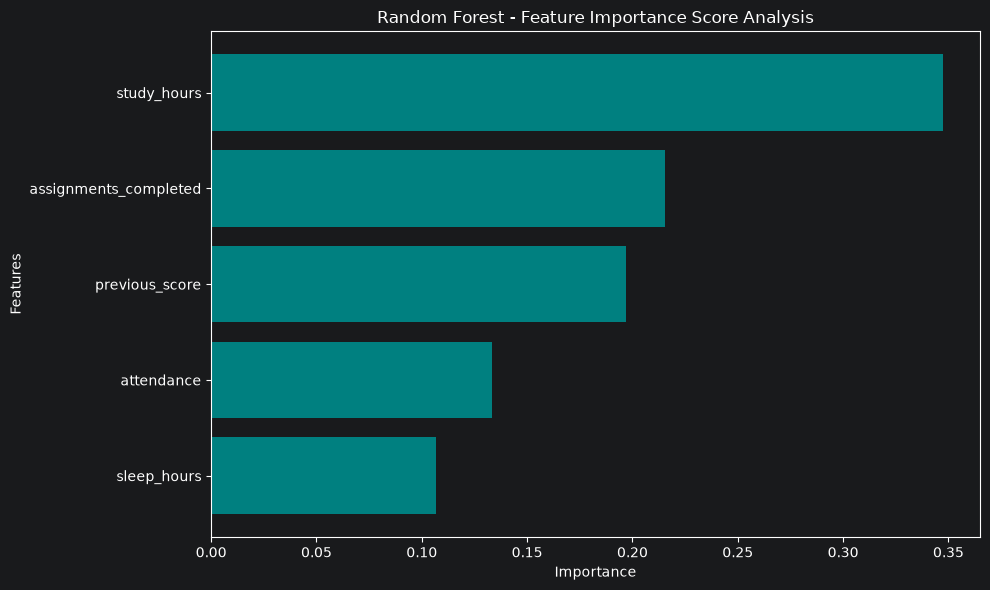

In [7]:
# 1. Feature importance
importances = xg_model.feature_importances_
feature_names = (
    X_train.columns
)

# 2. Converting to DataFrame
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- Feature Importance Scores ---")
print(feature_imp_df)

# 3. Virtualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance Score Analysis")
plt.gca().invert_yaxis()  # En yüksek olan en üstte gözüksün
plt.tight_layout()
plt.show()

In [8]:
# 1. Read the original raw CSV file directly
df = pd.read_csv("../datasets/student_dataset_10000_rows.csv")  # Adjust the path according to your own directory

# 2. Split into X and y
X = df.drop(
    ["placement_status","exam_score"], axis=1
)  # You should write your own target column name
y = df["placement_status"]

# 3. Split into Train-Test (test_size and random_state must be the SAME as in the analysis notebook!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Raw data loaded and split!")

# 4. Train the model with raw data
xg_raw_model = XGBClassifier(
    subsample=0.8,
    n_estimators=180,
    min_child_weight=3,
    max_depth=2,
    learning_rate=0.05,
    colsample_bytree=1.0,
    random_state=42,
)
xg_raw_model.fit(X_train_raw, y_train)

# 5. Train Set Performance For Raw Model
y_train_pred_raw = xg_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("         RAW DATA - TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy_raw:.4f}\n")
print("Train Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Test Set Performance For Raw Model (Real success)
y_test_pred_raw = xg_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("         RAW DATA - TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy_raw:.4f}\n")
print("Test Classification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

Raw data loaded and split!
         RAW DATA - TRAIN SET PERFORMANCE          
Train Accuracy: 0.9094

Train Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.82      0.58      0.68      1315
           1       0.92      0.97      0.95      6685

    accuracy                           0.91      8000
   macro avg       0.87      0.78      0.81      8000
weighted avg       0.90      0.91      0.90      8000

         RAW DATA - TEST SET PERFORMANCE           
Test Accuracy: 0.9010

Test Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.79      0.54      0.64       329
           1       0.91      0.97      0.94      1671

    accuracy                           0.90      2000
   macro avg       0.85      0.76      0.79      2000
weighted avg       0.89      0.90      0.89      2000

